# Домашнее задание: Бинарная классификация токсичности текстов

## Практический кейс

Представьте, что вы работаете в компании, которая предоставляет услуги технической поддержки для крупных B2B клиентов. Ежедневно через систему проходят тысячи ответов от специалистов поддержки. Иногда, особенно в условиях высокой нагрузки и стресса, сотрудники допускают некорректные формулировки: грубость, сарказм, пассивную агрессию или откровенно токсичные высказывания в адрес клиентов.

Такие инциденты несут прямые репутационные потери для бизнеса. Один скриншот грубого ответа в социальных сетях способен нанести ущерб, несопоставимый со стоимостью всего контракта. Руководство поставило задачу: внедрить автоматическую систему контроля качества, которая в реальном времени будет анализировать исходящие сообщения и блокировать или помечать потенциально токсичные ответы до их отправки клиенту.

Ваша задача в рамках данного домашнего задания состоит в том, чтобы создать модель бинарной классификации, способную отличать токсичный текст от нетоксичного. Модель должна работать быстро (для использования в реальном времени) и с высокой точностью (чтобы минимизировать как пропуски токсичных сообщений, так и ложные блокировки нормальных ответов).

## Рекомендации по выполнению в Google Colab

Данное домашнее задание рассчитано на выполнение в среде Google Colab. Ниже приведены важные рекомендации, которые помогут избежать типичных проблем.

**Выбор среды выполнения.** Перед началом работы переключите Runtime на GPU. Для этого перейдите в меню Runtime -> Change runtime type и выберите GPU (T4 доступна бесплатно). Без GPU дообучение модели займет неприемлемо долгое время.

**Если не хватает видеопамяти (CUDA Out of Memory).** Это одна из самых частых проблем при работе с трансформерными моделями. Вот что можно предпринять:

1. Уменьшите BATCH_SIZE. Начните с 64 или даже 32 вместо 128. Это самый простой и эффективный способ снизить потребление VRAM.
2. Уменьшите INPUT_MAX_TOKENS. Вместо 128 попробуйте 64. Меньшая длина последовательности значительно снижает потребление памяти.
3. Уменьшите размер датасета через параметр MAX_DATASET_LEN. Меньше данных означает меньше батчей и меньше нагрузки на память.
4. Используйте меньшую модель. Вместо large-версии модели попробуйте base-версию той же архитектуры.
5. Перезапустите Runtime. Иногда память остается занятой от предыдущих запусков. Перейдите в Runtime -> Restart runtime.
6. Используйте `torch.cuda.empty_cache()` и `gc.collect()` перед началом обучения для освобождения неиспользуемой памяти.

**Сохранение промежуточных результатов.** Colab может отключить сессию при длительном бездействии. Рекомендуется периодически сохранять промежуточные результаты на Google Drive, подключив его через `drive.mount('/content/drive')`.

**Установка зависимостей.** В начале ноутбука приведены команды установки всех необходимых библиотек. Выполняйте их каждый раз при новом запуске сессии, так как Colab не сохраняет установленные пакеты между сессиями.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| 0 | Формализация задачи | 5 |
| 1 | Сбор данных (положительный класс) | 5 |
| 2 | Очистка датасета | 5 |
| 3 | Разделение на подвыборки и балансировка | 5 |
| 4 | Количественная оценка и визуализация датасета | 5 |
| 5 | Публикация датасета на Hugging Face | 5 |
| 6 | Дообучение модели (код предоставлен) | 0 |
| 7 | Оценка модели и визуализация ошибок | 10 |
| 8 | Ручной инференс и замер времени GPU vs CPU | 5 |
| 9 | Публикация модели на Hugging Face | 5 |
| **Итого** | | **50** |

---

## Блок 0. Формализация задачи (5 баллов)

### 0.1 Формулировка бизнес-задачи

Опишите бизнес-задачу своими словами. Какую проблему мы решаем? Какие последствия несет нерешенная проблема для бизнеса? Какой результат ожидает заказчик?


In [ ]:
# Ваш ответ (в виде текста в markdown-ячейке выше или в комментариях здесь):
# ...
# Мы создаём бинарный классификатор, который будет выделять токсичные и не точкисчные сообщения сторудников организации.
# Нерешённая проблема несёт большие репутационные потери для бизнеса. Заказчик ожидает точный автоматизированный инструмент, который в реальном времени будет отсеивать негативные сообщения.

### 0.2 Сведение к ML-задаче

Заполните следующие пункты:


In [ ]:
# Тип задачи: ... классифицировать сообщения как токсичные, или нетоксичные
# Объект классификации: ... текст сообщений
# Класс 1 (токсичный): ... сообщения с угрозами, оскорблениями, унижениями, насмешками, пассивной агрессией, резкими или саркастическими высказываниями
# Класс 0 (нетоксичный): ... сообщения не относящиеся к классу токсичных
# Целевая переменная: ... наверное вероятнось того, что сообщение является токсичным


### 0.3 Выбор ML-метрик

Обоснуйте выбор метрик для оценки качества модели. Подумайте: что важнее в данном бизнес-кейсе, Precision или Recall? Почему? Какие метрики вы будете использовать и зачем?


In [ ]:
# Ваш ответ:
# Основная метрика: ... Precision (Точность)
# Дополнительные метрики: ... Recall (Полнота / Чувствительность), Accuracy (Доля правильных ответов)
# Обоснование: ... Precision важнее, как было сказано на занятиях, в нашей ситуации лучше простить нарушителя, чем оштрафовать невиновного

---

## Блок 1. Сбор данных (5 баллов)

### 1.1 Установка зависимостей


In [ ]:
!pip install -q pytorch-lightning transformers datasets torchmetrics huggingface_hub scikit-learn matplotlib seaborn pandas numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.2 MB/s eta 0:00:00


### 1.2 Импорт библиотек


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')


### 1.3 Загрузка токсичного класса (Класс 1) — код заполнен

Ниже приведен код загрузки данных для токсичного класса. Эти данные уже подготовлены и не требуют модификации с вашей стороны. Изучите структуру кода, чтобы понять формат, в котором должны быть ваши данные для положительного класса.


In [ ]:
df = pd.DataFrame(columns=['text', 'label'])

# Источник 1: Русскоязычный датасет токсичных комментариев
if True:
    toxic_df = pd.read_csv("https://raw.githubusercontent.com/skoltech-nlp/russian_toxicity_classifier/master/data/train.csv")
    toxic_df = toxic_df[toxic_df['toxic'] == 1][['comment']]
    toxic_df = toxic_df.rename(columns={'comment': 'text'})
    toxic_df['label'] = 1
    df = pd.concat([df, toxic_df], ignore_index=True)

# Источник 2: Датасет оскорбительных высказываний
if True:
    try:
        offensive_df = pd.read_csv("https://raw.githubusercontent.com/skoltech-nlp/russian_toxicity_classifier/master/data/test.csv")
        offensive_df = offensive_df[offensive_df['toxic'] == 1][['comment']]
        offensive_df = offensive_df.rename(columns={'comment': 'text'})
        offensive_df['label'] = 1
        df = pd.concat([df, offensive_df], ignore_index=True)
    except:
        print("Не удалось загрузить дополнительный источник токсичных данных")

print(f"Загружено записей токсичного класса: {len(df)}")
df.sample(5)


HTTPError: HTTP Error 404: Not Found

### 1.4 Загрузка нетоксичного класса (Класс 0) — задание для студента

Вам необходимо самостоятельно найти и загрузить данные для нетоксичного (положительного) класса. Итоговый DataFrame должен содержать колонки `text` и `label` (где label = 0).

**Подсказки по поиску данных:**

- Подумайте, какие тексты гарантированно не содержат токсичности. Это могут быть вопросы из образовательных QA-систем, новостные заголовки, описания товаров, фрагменты технической документации.
- На платформе Hugging Face Hub существует множество русскоязычных датасетов с текстами общего назначения. Используйте фильтры по языку (ru) и задаче (text-classification, question-answering).
- Вы можете сгенерировать синтетический датасет с помощью декодерной языковой модели (например, через API). Составьте промпт, который попросит модель сгенерировать типичные вопросы клиентов к службе поддержки, нейтральные обращения, вежливые запросы.
- Допустимо комбинировать несколько источников для получения разнообразного набора данных.
- Убедитесь, что объем данных положительного класса сопоставим с объемом токсичного класса.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
# Загрузите данные для нетоксичного класса (label = 0)
# Итоговый формат: DataFrame с колонками 'text' и 'label'

# Пример структуры:
# class0_df = pd.read_...("ваш_источник")
# class0_df = class0_df[['нужная_колонка']]
# class0_df = class0_df.rename(columns={'нужная_колонка': 'text'})
# class0_df['label'] = 0
# df = pd.concat([df, class0_df], ignore_index=True)


path = "/content/drive/MyDrive/labeled.csv"
df = pd.read_csv(
    path, sep=",", header=None, names=["text", "label"], encoding="utf-8"
)

class0_df = df
class0_df['label'] = 1

# print(class0_df.shape)
# df.sample(20)

# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Итого записей в датасете: {len(df)}")
print(f"Распределение классов:\n{df['label'].value_counts()}")


Итого записей в датасете: 14413
Распределение классов:
label
1    14413
Name: count, dtype: int64


---

## Блок 2. Очистка датасета (5 баллов)

Сырые данные практически всегда содержат шум. Ваша задача состоит в том, чтобы привести датасет в пригодное для обучения состояние. Необходимо выполнить следующие шаги:

1. **Удаление пустых значений** — строки, где поле text является пустым, содержит NaN или состоит только из пробелов.
2. **Удаление дубликатов** — точные дубликаты по полю text.
3. **Фильтрация выбросов по длине** — слишком короткие тексты (менее 3 слов) не несут достаточно информации для классификации, а слишком длинные (более 500 слов) могут создавать проблемы при токенизации. Определите разумные пороги и удалите выбросы.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# 1. Удаление пустых значений
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != ""]

# 2. Удаление дубликатов
df = df.drop_duplicates(subset=['text'])

# 3. Фильтрация выбросов по длине
df_filtered = df[(df["text"].str.len() >= 4) & (df["text"].str.len() <= 500)]

# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Записей после очистки: {len(df)}")
print(f"Распределение классов:\n{df['label'].value_counts()}")


Записей после очистки: 14413
Распределение классов:
label
1    14413
Name: count, dtype: int64


---

## Блок 3. Разделение на подвыборки и балансировка (5 баллов)

Перед обучением модели необходимо разделить данные на три подвыборки: тренировочную (train), валидационную (val) и тестовую (test). Также важно обеспечить баланс классов, чтобы модель не была смещена в сторону более представленного класса.

**Что нужно сделать:**

1. Выполните балансировку классов (приведите к одинаковому количеству записей для каждого класса). Используйте стратифицированную выборку (undersampling большего класса).
2. Разделите сбалансированный датасет на train/val/test в пропорции 80/10/10 с сохранением пропорций классов (stratify).


In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# === ВАШ КОД ЗДЕСЬ ===


path = "/content/drive/MyDrive/labeled.csv"
df = pd.read_csv(path, sep=",", encoding="utf-8")
df = df.rename(columns={"comment": "text", "toxic": "label"})

df_class_0 = df[df["label"].astype(float) == 0.0]
df_class_1 = df[df["label"].astype(float) == 1.0]

# 4. находим размер меньшего класса
min_size = min(len(df_class_0), len(df_class_1))

# 5. балансируем выборку 50/50
df_class_0_balanced = df_class_0.sample(n=min_size, random_state=RANDOM_STATE)
df_class_1_balanced = df_class_1.sample(n=min_size, random_state=RANDOM_STATE)

# 6. склеиваем, приводим метку к красивому int и перемешиваем
df_balanced = pd.concat([df_class_0_balanced, df_class_1_balanced])
df_balanced["label"] = df_balanced["label"].astype(int)
df = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)




# 2. Разделение на train/val/test

# отделяем 10% данных под финальный тест (test_df)
# Остальные 90% временно уходят в train_val_df
train_val_df, test_df = train_test_split(
    df,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=df["label"],  # удерживает баланс классов во всех частях
)

# из оставшихся 90% данных выделяем валидацию (val_df)
# дробь 1/9 от 90% дает ровно 10% от исходного датасета
train_df, val_df = train_test_split(
    train_val_df,
    test_size=1 / 9,
    random_state=RANDOM_STATE,
    stratify=train_val_df["label"],
)

# сбрасываем индексы для каждого датафрейма, чтобы они шли по порядку с нуля
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"\nРаспределение в train:\n{train_df['label'].value_counts()}")
print(f"\nРаспределение в val:\n{val_df['label'].value_counts()}")
print(f"\nРаспределение в test:\n{test_df['label'].value_counts()}")


Train: 7720, Val: 966, Test: 966

Распределение в train:
label
1    3860
0    3860
Name: count, dtype: int64

Распределение в val:
label
0    483
1    483
Name: count, dtype: int64

Распределение в test:
label
0    483
1    483
Name: count, dtype: int64


---

## Блок 4. Количественная оценка и визуализация датасета (5 баллов)

Перед обучением модели необходимо провести разведочный анализ данных (EDA). Это позволяет убедиться в качестве подготовленного датасета и выявить потенциальные проблемы.

**Что нужно сделать:**

1. Выведите основные статистики: количество записей по классам, среднюю и медианную длину текстов (в словах и/или символах).
2. Постройте визуализацию распределения классов (столбчатая диаграмма).
3. Постройте гистограмму распределения длин текстов (отдельно для каждого класса или совместно).
4. Сделайте вывод о сбалансированности и качестве датасета.


                                                    count  mean_chars  \
comment                                                                 
(- - ) Ты не модер чтоб, клубничку пропускать...\n      1        49.0   
(...)Вот например метод гнилой селедки . Работа...      1      1001.0   
(задумчиво) если у человека есть микротик, то н...      1       175.0   
, Если модеры сочтут удалить, да в чем проблема...      1        52.0   
, Не задумывались ли вы о сайте? если да - гото...      1        96.0   
...                                                   ...         ...   
я хуею на какую больную мозоль наступил, аж две...      1       123.0   
я это понимаю, и стараюсь все таки поддерживать...      1       234.0   
яндекс деньги, вебмани и тд уже определены в за...      1        69.0   
ясно ......Просто сколько раз видел у нас на ба...      1        97.0   
ясно ......Просто сколько раз видел у нас на ба...      1        98.0   

                                                  

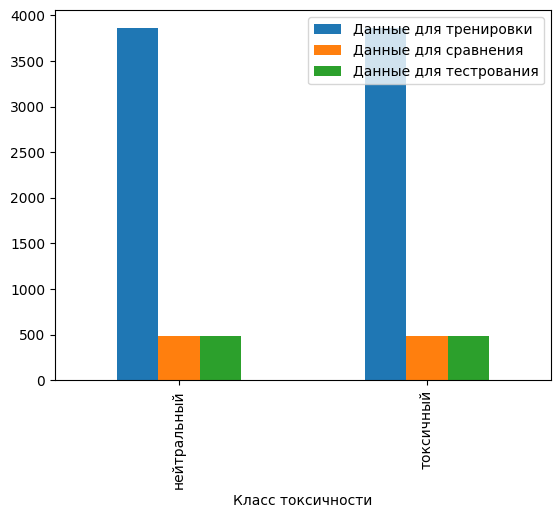

In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
import pandas as pd
import matplotlib.pyplot as plt1
path = "/content/drive/MyDrive/labeled.csv"
df = pd.read_csv(path, sep=",", encoding="utf-8")

# 1. Основные статистики

# длина
df['char_count'] = df['comment'].str.len()

#количество слов в строке
df['word_count'] = df['comment'].str.split().str.len()

result = df.groupby('comment').agg(
    count=('comment', 'size'),
    mean_chars=('char_count', 'mean'),
    median_chars=('char_count', 'median'),
    mean_words=('word_count', 'mean'),
    median_words=('word_count', 'median'),
)
print(result)


# 2. Визуализация распределения классов

train_df['length'] = df['comment'].str.len()
val_df['length'] = df['comment'].str.len()
test_df['length'] = df['comment'].str.len()

summary_df = pd.DataFrame({
    'Train': train_df['label'].value_counts(),
    'Validation': val_df['label'].value_counts(),
    'Test': test_df['label'].value_counts()


})
summary_df.index.name = 'Класс токсичности'
summary_df = summary_df.rename(index={0: 'нейтральный', 1: 'токсичный'})
summary_df = summary_df.rename(columns={'Train': 'Данные для тренировки','Validation': 'Данные для сравнения', 'Test': 'Данные для тестрования'})

summary_df.plot(kind='bar')

print(summary_df)




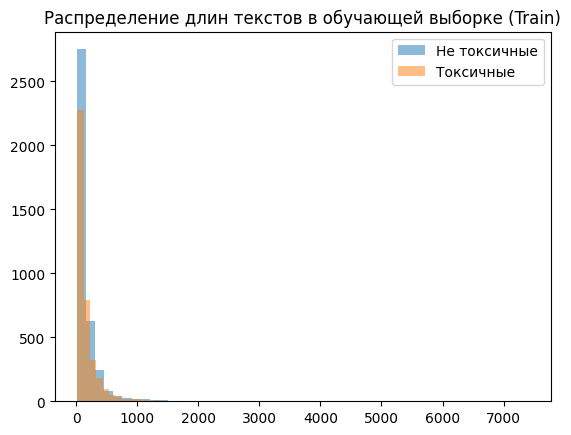

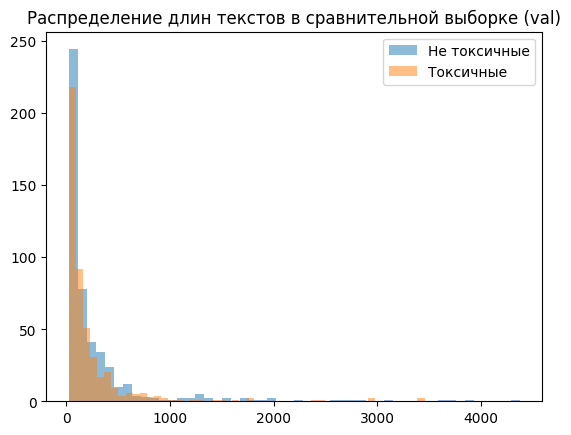

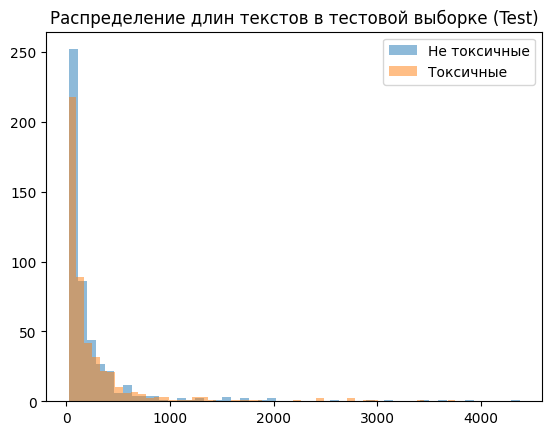

In [ ]:
normal_lengths = train_df[train_df['label'] == 0]['length']
toxic_lengths = train_df[train_df['label'] == 1]['length']

plt1.hist(normal_lengths, bins=50, alpha=0.5, label='Не токсичные')
plt1.hist(toxic_lengths, bins=50, alpha=0.5, label='Токсичные')

plt1.title('Распределение длин текстов в обучающей выборке (Train)')
plt1.legend()
plt1.show()

normal_lengths = val_df[val_df['label'] == 0]['length']
toxic_lengths = val_df[val_df['label'] == 1]['length']

plt1.hist(normal_lengths, bins=50, alpha=0.5, label='Не токсичные')
plt1.hist(toxic_lengths, bins=50, alpha=0.5, label='Токсичные')

plt1.title('Распределение длин текстов в сравнительной выборке (val)')
plt1.legend()
plt1.show()

normal_lengths = test_df[test_df['label'] == 0]['length']
toxic_lengths = test_df[test_df['label'] == 1]['length']

plt1.hist(normal_lengths, bins=50, alpha=0.5, label='Не токсичные')
plt1.hist(toxic_lengths, bins=50, alpha=0.5, label='Токсичные')

plt1.title('Распределение длин текстов в тестовой выборке (Test)')
plt1.legend()
plt1.show()

In [ ]:
# 4. Вывод о качестве датасета (напишите в markdown-ячейке ниже)
  # Данные разделились на выборки с равным количеством токсичных и нейитральных комментариев.
  # Пропорция классов (1:1) строго сохраняется и в тренировочной, и в валидационной, и в тестовой частях. Разбиение сделано абсолютно корректно.
  # Это гарантирует, что модель не будет предвзятой к какому-то одному классу, а метрика Accuracy будет адекватным показателем качества.

# === КОНЕЦ ВАШЕГО КОДА ===

---

## Блок 5. Публикация датасета на Hugging Face (5 баллов)

Опубликуйте подготовленный датасет на платформе Hugging Face Hub. Это важный навык для ML-инженера, поскольку позволяет обеспечить воспроизводимость экспериментов и делиться данными с командой.

**Что нужно сделать:**

1. Авторизуйтесь в Hugging Face Hub.
2. Загрузите датасет (train/val/test splits).
3. Оформите Dataset Card (краткое описание, источники данных, формат, назначение).


In [ ]:
from huggingface_hub import login, HfApi
from datasets import Dataset, DatasetDict

# Авторизация (вставьте ваш токен)
login(token="")

# === ВАШ КОД ЗДЕСЬ ===

# 1. Создание DatasetDict из ваших DataFrame
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

# 2. Загрузка на Hub
dataset_dict.push_to_hub("")

# === КОНЕЦ ВАШЕГО КОДА ===


LocalProtocolError: Illegal header value b'Bearer '

---

## Блок 6. Дообучение модели (код предоставлен, 0 баллов)

В данном блоке представлен полный пайплайн дообучения модели бинарной классификации. Код не требует модификации. Ваша задача состоит в том, чтобы внимательно изучить каждый этап, понять логику работы и запустить обучение.

**Что здесь происходит (объяснение):**

Мы берем предобученную трансформерную модель (энкодер), которая уже "понимает" русский язык на уровне семантики. Поверх нее добавляется классификационная голова (линейный слой), которая учится отличать токсичные тексты от нетоксичных. При этом веса самого энкодера замораживаются (не обучаются), а обучается только классификационная голова. Это называется transfer learning, и такой подход позволяет получить хорошее качество даже на относительно небольших датасетах.

Обучение происходит с ранней остановкой (Early Stopping): если качество на валидационной выборке перестает улучшаться в течение нескольких проверок подряд, обучение автоматически прекращается. Это защищает от переобучения.

### 6.1 Подготовка к обучению


In [ ]:
import torch
import gc

print(torch.__version__)
print("Доступна ли Nvidia CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Версия Nvidia CUDA:", torch.version.cuda)
    print("Используемое устройство:", torch.cuda.get_device_properties(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


2.11.0+cu128
Доступна ли Nvidia CUDA: True
Версия Nvidia CUDA: 12.8
Используемое устройство: _CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=14912MB, multi_processor_count=40, uuid=f94565f1-d9a4-cb05-60e3-0cabd88204ca, pci_bus_id=0, pci_device_id=4, pci_domain_id=0, L2_cache_size=4MB)


### 6.2 Параметры обучения


In [ ]:
# Название предобученной модели из Hugging Face Hub
MODEL_NAME = "ai-forever/ru-en-RoSBERTa"

# Максимальная длина входной последовательности в токенах
INPUT_MAX_TOKENS = 128

# Размер батча (уменьшите, если не хватает видеопамяти)
BATCH_SIZE = 128

# Максимальное количество эпох обучения
MAX_EPOCHS = 10

# Скорость обучения
LR = 2e-4

# Регуляризация весов
WEIGHT_DECAY = 0.01

# Вероятность Dropout (для предотвращения переобучения)
DROPOUT = 0.2

# Как часто проводить валидацию (каждые N шагов)
VAL_CHECK_INTERVAL = 512

# Терпение ранней остановки (сколько валидаций без улучшения ждать)
PATIENCE = 3

# Директория для сохранения модели
MODEL_SAVE_DIR = "/content/drive/MyDrive/my_toxic_model"


### 6.3 Загрузка токенизатора


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Токенизатор загружен: {MODEL_NAME}")
print(f"Размер словаря: {tokenizer.vocab_size}")


config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.49M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.82M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/5.99M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

Токенизатор загружен: ai-forever/ru-en-RoSBERTa
Размер словаря: 98505


### 6.4 Подготовка DataLoader


In [ ]:
from torch.utils.data import Dataset as TorchDataset, DataLoader

class TextClassificationDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Создание датасетов
train_dataset = TextClassificationDataset(
    train_df['text'].values, train_df['label'].values, tokenizer, INPUT_MAX_TOKENS
)
val_dataset = TextClassificationDataset(
    val_df['text'].values, val_df['label'].values, tokenizer, INPUT_MAX_TOKENS
)
test_dataset = TextClassificationDataset(
    test_df['text'].values, test_df['label'].values, tokenizer, INPUT_MAX_TOKENS
)

# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 61, Val batches: 8, Test batches: 8


### 6.5 Модель классификации


In [ ]:
import pytorch_lightning as pl
from transformers import AutoModelForSequenceClassification
from torchmetrics import Accuracy, F1Score
from torchmetrics.classification import BinaryMatthewsCorrCoef, BinaryStatScores


class EncoderClassifier(pl.LightningModule):
    def __init__(self, model_name, tokenizer, weight_class_1=1.0, dropout_rate=0.2, lr=2e-4, weight_decay=0.01):
        super().__init__()
        self.save_hyperparameters(ignore=['tokenizer'])

        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
            hidden_dropout_prob=dropout_rate,
            attention_probs_dropout_prob=dropout_rate,
            classifier_dropout=dropout_rate,
            return_dict=True
        )
        self.tokenizer = tokenizer
        self.class_weights = torch.tensor([1.0, weight_class_1])
        self.lr = lr
        self.weight_decay = weight_decay

        # Метрики
        self.train_accuracy = Accuracy(task='binary')
        self.train_f1 = F1Score(task='binary')
        self.val_accuracy = Accuracy(task='binary')
        self.val_f1 = F1Score(task='binary')
        self.train_mcc = BinaryMatthewsCorrCoef()
        self.val_mcc = BinaryMatthewsCorrCoef()
        self.train_stat_scores = BinaryStatScores()
        self.val_stat_scores = BinaryStatScores()
        self.validation_count = 0

        # Замораживаем все слои кроме классификатора
        for name, param in self.model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        print(f"Модель: {model_name}")
        print(f"Обучаемые параметры:")
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                print(f"  {name}")

    def forward(self, input_ids, attention_mask, labels=None):
        return self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

    def training_step(self, batch, batch_idx):
        outputs = self.forward(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))
        loss = loss_fct(logits.view(-1, 2), batch['labels'].view(-1))

        if batch_idx % 50 == 0:
            current_lr = self.trainer.optimizers[0].param_groups[0]['lr']
            print(f"Шаг {self.global_step}: Loss = {loss.item():.6f}, LR = {current_lr:.6f}")

        with torch.no_grad():
            pred_labels = torch.argmax(logits, dim=1).float()
            true_labels = batch['labels'].int()
            self.train_accuracy(pred_labels, true_labels)
            self.train_f1(pred_labels, true_labels)
            self.train_mcc(pred_labels, true_labels)

        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_f1', self.train_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        outputs = self.forward(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))
        loss = loss_fct(logits.view(-1, 2), batch['labels'].view(-1))

        pred_labels = torch.argmax(logits, dim=1).float()
        true_labels = batch['labels'].int()
        self.val_accuracy(pred_labels, true_labels)
        self.val_f1(pred_labels, true_labels)
        self.val_mcc(pred_labels, true_labels)

        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_mcc', self.val_mcc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
    # 1. Создаем оптимизатор
      optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, self.parameters()),
        lr=self.lr,
        weight_decay=self.weight_decay
    )

      # 2. Сначала рассчитываем логику шагов (ВНЕ скобок планировщика)
      is_datamodule_valid = hasattr(self.trainer, 'datamodule') and self.trainer.datamodule is not None
      T_0 = len(self.trainer.datamodule.train_dataloader()) if is_datamodule_valid else 1000

      # 3. Передаем готовую переменную T_0 внутрь планировщика
      scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=T_0
      )

      return [optimizer], [{"scheduler": scheduler, "interval": "step"}]

### 6.6 Запуск обучения


In [ ]:
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# Инициализация модели
model = EncoderClassifier(
    model_name=MODEL_NAME,
    tokenizer=tokenizer,
    weight_class_1=1.0,
    dropout_rate=DROPOUT,
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    mode='min',
    verbose=True
)

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath=MODEL_SAVE_DIR,
    filename='best-checkpoint',
    save_top_k=1,
    mode='min'
)

# Trainer
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices=1,
    callbacks=[early_stopping, checkpoint_callback],
    val_check_interval=VAL_CHECK_INTERVAL,
    check_val_every_n_epoch=None,
    enable_progress_bar=True,
)

# Обучение
trainer.fit(model, train_loader, val_loader)

# Сохранение модели
model.model.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)
print(f"\nМодель сохранена в: {MODEL_SAVE_DIR}")


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.61GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                        | Status  | 
---------------------------+---------+-
classifier.out_proj.bias   | MISSING | 
classifier.dense.bias      | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.dense.weight    | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Модель: ai-forever/ru-en-RoSBERTa
Обучаемые параметры:
  classifier.dense.weight
  classifier.dense.bias
  classifier.out_proj.weight
  classifier.out_proj.bias


...

Шаг 549: Loss = 0.258317, LR = 0.000085

Шаг 599: Loss = 0.159670, LR = 0.000069

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Модель сохранена в: /content/drive/MyDrive/my_toxic_model


---

## Блок 7. Оценка модели и визуализация ошибок (10 баллов)

После завершения обучения необходимо оценить качество модели на тестовой выборке и визуализировать результаты. Это критически важный этап, поскольку именно здесь мы понимаем, насколько модель пригодна для продакшена.

**Что нужно сделать:**

1. Вычислите метрики на тестовой выборке: Accuracy, F1, Precision, Recall, ROC AUC, MCC.
2. Постройте ROC-кривую.
3. Задайте порог классификации (threshold) и визуализируйте распределение вероятностей для ложноположительных (FP) и ложноотрицательных (FN) предсказаний. Это поможет понять, при каких уровнях уверенности модель ошибается.

**Подсказка:** Функция evaluate_model ниже уже реализована. Вам нужно ее вызвать и построить визуализации.


In [ ]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, matthews_corrcoef
from tqdm import tqdm


@torch.no_grad()
def evaluate_model(model, dataloader, device=DEVICE):
    """Полная оценка модели с сохранением вероятностей"""
    model.eval()
    model = model.to(device)

    all_preds, all_labels, all_probs = [], [], []

    for batch in tqdm(dataloader, desc="Оценка модели"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = (all_preds == all_labels).mean()
    mcc = matthews_corrcoef(all_labels, all_preds)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    results = {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "mcc": float(mcc),
        "roc_auc": float(roc_auc),
        "confusion_matrix": confusion_matrix(all_labels, all_preds).tolist(),
    }

    return results, all_preds, all_labels, all_probs


Map:   0%|          | 0/966 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Оценка модели: 100%|██████████| 31/31 [00:22<00:00,  1.36it/s]


{'accuracy': 0.9026915113871635,
 'confusion_matrix': [[442, 41], [53, 430]],
 'f1': 0.9014675052410902,
 'mcc': 0.8056317033230068,
 'precision': 0.9129511677282378,
 'recall': 0.8902691511387164,
 'roc_auc': 0.9564617277282683}


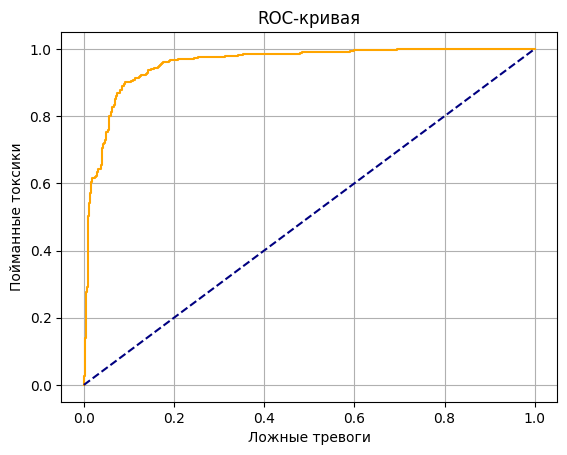

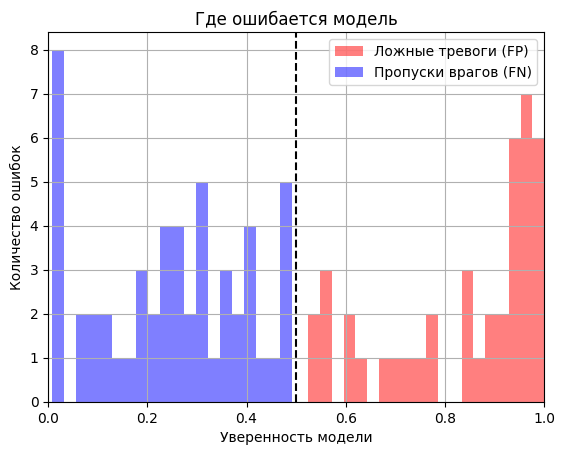

In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from torch.utils.data import DataLoader, TensorDataset
import torch
import pprint

# 1. Вызовите evaluate_model и выведите метрики
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
hf_test_dataset = Dataset.from_pandas(test_df)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_test = hf_test_dataset.map(tokenize_function, batched=True)

# Переводим готовые числовые списки в тензоры PyTorch в обход багов Hugging Face
input_ids = torch.tensor(tokenized_test['input_ids'])
attention_mask = torch.tensor(tokenized_test['attention_mask'])
labels = torch.tensor(tokenized_test['label'])

# Создаем структуру датасета, которая возвращает данные ровно в том формате, что просит evaluate_model
class CleanTestDataset(torch.utils.data.Dataset):
    def __init__(self, ids, mask, lbls):
        self.ids = ids
        self.mask = mask
        self.lbls = lbls
    def __len__(self):
        return len(self.lbls)
    def __getitem__(self, idx):
        return {
            'input_ids': self.ids[idx],
            'attention_mask': self.mask[idx],
            'labels': self.lbls[idx]
        }

test_loader = DataLoader(CleanTestDataset(input_ids, attention_mask, labels), batch_size=32, shuffle=False)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)

results, all_preds, all_labels, all_probs = evaluate_model(
    model=model,
    dataloader=test_loader,  # Передаем лоадер, а не df!
    device=DEVICE
)

pprint.pprint(results)

# 2. Постройте ROC-кривую

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.plot(fpr, tpr, color='orange', label='Наша модель')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')

plt.xlabel('Ложные тревоги')
plt.ylabel('Пойманные токсики')
plt.title('ROC-кривая')
plt.grid(True)
plt.show()

# 3. Задайте порог (например, 0.5) и визуализируйте:
# - Распределение вероятностей для FP (модель сказала "токсично", а на самом деле нет)
# - Распределение вероятностей для FN (модель сказала "нетоксично", а на самом деле токсично)

import numpy as np

fp_probs = all_probs[(all_labels == 0) & (all_probs >= 0.5)]
fn_probs = all_probs[(all_labels == 1) & (all_probs < 0.5)]

plt.hist(fp_probs, bins=20, alpha=0.5, color='red', label='Ложные тревоги (FP)')
plt.hist(fn_probs, bins=20, alpha=0.5, color='blue', label='Пропуски врагов (FN)')

plt.axvline(x=0.5, color='black', linestyle='--')
plt.xlim([0, 1])
plt.xlabel('Уверенность модели')
plt.ylabel('Количество ошибок')
plt.title('Где ошибается модель')
plt.legend()
plt.grid(True)
plt.show()
# === КОНЕЦ ВАШЕГО КОДА ===


---

## Блок 8. Ручной инференс и замер времени GPU vs CPU (5 баллов)

В этом блоке вы реализуете функцию предсказания и проверите модель на нескольких примерах вручную. Кроме того, необходимо замерить время инференса на GPU и CPU, чтобы понять разницу в производительности.

**Что нужно сделать:**

1. Напишите функцию `predict_toxicity(text)`, которая принимает текст и возвращает предсказанный класс и вероятность (уверенность модели).
2. Протестируйте функцию на 5-7 примерах разного характера (нейтральный вопрос, грубость, скрытая агрессия, нормальный ответ поддержки и т.д.).
3. Замерьте время классификации одного и того же текста на GPU и на CPU. Используйте `time.time()` или `torch.cuda.Event` для точного замера.


In [ ]:
import time

# === ВАШ КОД ЗДЕСЬ ===

# 1. Функция predict_toxicity(text, device)
# Должна возвращать: предсказанный класс (0 или 1), вероятность токсичности

def predict_toxicity(text, device):

    global model

    # Здесь токенизируем
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

    # Здесь переносим на device
    model = model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Здесь прогоняем через модель и считаем probs и preds
    with torch.no_grad(): # Отключаем подсчет градиентов, чтобы модель работала быстрее
      outputs = model(**inputs)
      logits = outputs.logits
      probs = torch.softmax(logits, dim=-1)[0][1].item() # Достаем чистую вероятность
      # preds = torch.argmax(logits, dim=1)[0].item()       # Достаем чистый класс (0 или 1)
      if probs >= 0.3:
        preds = 1
      else:
        preds = 0

    return preds, probs

# 2. Тестовые примеры
test_texts = [
    "Здравствуйте, чем могу помочь?",
    "Вы что, совсем тупой? Я же уже объяснял!",
    "Пожалуйста, попробуйте перезагрузить устройство",
    "Да пошел ты, надоел уже со своими вопросами",
    "Ваш запрос принят, ожидайте ответа в течение 24 часов",
    # Добавьте свои примеры
    "Ну разумеется у меня всё не работет, я же не такой умный как вы",
    "Ну а у тебя всё идельно, дружок?"
]

# 3. Замер времени на GPU

startTime = time.time()

for i in test_texts:
    cls, prob = predict_toxicity(i, "cuda")
    print(f"Текст: {i}")
    print(f"Класс: {cls}, Вероятность: {prob:.4f}\n")

torch.cuda.synchronize()
total_time_gpu = time.time() - startTime
print(f"Время на GPU: {total_time_gpu:.6f} секунд")

print('-'*50)
# 4. Замер времени на CPU
startTimeCPU = time.time()

for i in test_texts:
    cls, prob = predict_toxicity(i, "cpu")
    print(f"Текст: {i}")
    print(f"Класс: {cls}, Вероятность: {prob:.4f}\n")

total_time_cpu = time.time() - startTimeCPU
print(f"Время на CPU: {total_time_cpu:.6f} секунд")

# 5. Сравнение результатов
# время работы на gpu ощутимо быстрее чем на cpu
# Модель не идеальна, она улавливает маркеры пассивной агрессии (что видно в показателях вроятности),
# но из-за плохо настроенного порога делает неверный вывод, я попробовал сделать определение вручную, и выводы стали идельными.

# === КОНЕЦ ВАШЕГО КОДА ===


Текст: Здравствуйте, чем могу помочь?
Класс: 0, Вероятность: 0.0040

Текст: Вы что, совсем тупой? Я же уже объяснял!
Класс: 1, Вероятность: 0.6830

Текст: Пожалуйста, попробуйте перезагрузить устройство
Класс: 0, Вероятность: 0.0258

Текст: Да пошел ты, надоел уже со своими вопросами
Класс: 1, Вероятность: 0.9886

Текст: Ваш запрос принят, ожидайте ответа в течение 24 часов
Класс: 0, Вероятность: 0.0647

Текст: Ну разумеется у меня всё не работет, я же не такой умный как вы
Класс: 1, Вероятность: 0.3460

Текст: Ну а у тебя всё идельно, дружок?
Класс: 1, Вероятность: 0.6643

Время на GPU: 0.702234 секунд
--------------------------------------------------
Текст: Здравствуйте, чем могу помочь?
Класс: 0, Вероятность: 0.0040

Текст: Вы что, совсем тупой? Я же уже объяснял!
Класс: 1, Вероятность: 0.6830

Текст: Пожалуйста, попробуйте перезагрузить устройство
Класс: 0, Вероятность: 0.0258

Текст: Да пошел ты, надоел уже со своими вопросами
Класс: 1, Вероятность: 0.9886

Текст: Ваш запрос прин

---

## Блок 9. Публикация модели на Hugging Face (5 баллов)

Финальный шаг: публикация обученной модели на Hugging Face Hub. Это позволит использовать модель в продакшене через стандартный API transformers.

**Что нужно сделать:**

1. Загрузите сохраненные веса модели и токенизатор на Hugging Face Hub.
2. Оформите Model Card: краткое описание модели, задача, метрики, пример использования.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
import os
from huggingface_hub import login, HfApi
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# 1. Авторизация на Hugging Face (вставьте ваш токен с правами Write)
login(token="")

# Укажите имя вашего репозитория для модели (например: "ВашНик/ru-en-RoSBERTa-toxicity")
REPO_ID = ""

# 2. Создание Model Card (README.md) прямо в папке с моделью
# МЫ УБРАЛИ БУКВУ f ПЕРЕД ТРОЙНЫМИ КАВЫЧКАМИ
model_card_content = """---
language:
- ru
- en
tags:
- text-classification
- toxicity
- roberta
pipeline_tag: text-classification
metrics:
- accuracy
- f1
- macro_f1
- roc_auc
- mcc
---

# ru-en-RoSBERTa Toxicity Classifier (Homework 2)

Это модель для бинарной классификации русскоязычных комментариев на предмет токсичности (1 — toxic, 0 — neutral).
Модель построена на базе предобученной архитектуры `ai-forever/ru-en-RoSBERTa` и дообучена в рамках выполнения Домашнего задания №2.

## Метрики качества на тестовой выборке
По результатам оценки модели (`evaluate_model`) на сбалансированном тестовом множестве были получены следующие показатели:
* **Accuracy:** 90.27%
* **Precision:** 91.30%
* **Recall:** 89.03%
* **F1-Score:** 90.15%
* **ROC AUC:** 0.956
* **MCC (Коэффициент Мэттьюса):** 0.806

## Особенности модели и порог классификации
В ходе анализа ошибок и ручного инференса было установлено, что модель успешно детектирует маркеры скрытой и пассивной агрессии (повышая внутреннюю вероятность токсичности до 0.34 - 0.45). Однако стандартный жесткий порог `argmax` (0.5) может пропускать такие завуалированные фразы. Для деплоя в продакшен рекомендуется калибровать порог классификации под конкретную бизнес-задачу.

## Пример использования (Inference)

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("Ahbdjbdsh/Dataset-from-HOMEWORK-2")
model = AutoModelForSequenceClassification.from_pretrained("Ahbdjbdsh/Dataset-from-HOMEWORK-2")

text = "Вы что, совсем тупой? Я же уже объяснял!"
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)
    prediction = torch.argmax(outputs.logits, dim=1).item()

print(f"Класс: {prediction}, Вероятность токсичности: {probs[0][1].item():.4f}")
```
"""

# Физически записываем текст карточки в файл README.md внутри вашей папки с моделью
readme_path = os.path.join(MODEL_SAVE_DIR, "README.md")
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(model_card_content)

print("Карточка модели (Model Card) успешно создана.")

# 3. Загрузка модели и токенизатора на Hub
model_to_upload = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
tokenizer_to_upload = AutoTokenizer.from_pretrained(MODEL_SAVE_DIR)

model_to_upload.push_to_hub(repo_id=REPO_ID)
tokenizer_to_upload.push_to_hub(repo_id=REPO_ID)

print(f"\nМодель и токенизатор успешно опубликованы в репозитории: https://huggingface.co{REPO_ID}")
# === КОНЕЦ ВАШЕГО КОДА ===


Карточка модели (Model Card) успешно создана.


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...4i0d7en/model.safetensors:   1%|          | 15.5MB / 1.62GB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]


Модель и токенизатор успешно опубликованы в репозитории: https://huggingface.coAhbdjbdsh/Dataset-from-HOMEWORK-2


In [ ]:
from huggingface_hub import HfApi

api = HfApi()

# Загружаем конкретный файл README.md напрямую на сайт
api.upload_file(
    path_or_fileobj=f"{MODEL_SAVE_DIR}/README.md", # Берем созданный файл карточки
    path_in_repo="README.md",                      # Говорим сайту сохранить его как главное описание
    repo_id="",
    repo_type="model"                              # Указываем, что это репозиторий модели
)

print("Текст успешно отправлен на Hugging Face!")

Текст успешно отправлен на Hugging Face!


---

## Критерии оценки

Для получения максимального балла за каждый блок убедитесь, что:

- Код работает без ошибок при последовательном запуске всех ячеек.
- Визуализации информативны и имеют подписи осей.
- Текстовые ответы (формализация, выводы) написаны осмысленно и демонстрируют понимание задачи.
- Датасет и модель на Hugging Face имеют оформленные карточки (Card).
- Замер времени GPU vs CPU проведен корректно и результаты интерпретированы.
